In [1]:
import pandas as pd
import numpy as np
import os
import json
import matplotlib.pyplot as plt
os.chdir("..")

In [2]:
print(os.getcwd())

c:\Users\vkamat01\hedging-txtclf-experiments


## Error-Driven Augmentation
Targets false positives from the baseline classifier — negatives the model
incorrectly calls hedges. Two sampling strategies:
- Strategy A: High-confidence false positives (calibrated score >= 0.3)
- Strategy B: Diversity-based sampling via KMeans clustering
Both strategies feed into Type 3 hard contrastive generation with the 70B model.

In [3]:
from sklearn.linear_model import LogisticRegression
from venn_abers import VennAbersCalibrator
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

In [4]:
# Load embeddings
X_train = np.load("data/processed/embeddings/X_train.npy")
y_train = np.load("data/processed/embeddings/y_train.npy")
X_cal = np.load("data/processed/embeddings/X_cal.npy")
y_cal = np.load("data/processed/embeddings/y_cal.npy")
X_test = np.load("data/processed/embeddings/X_test.npy")
y_test = np.load("data/processed/embeddings/y_test.npy")

print(f"Train: {X_train.shape} | Positives: {y_train.sum()}")
print(f"Cal:   {X_cal.shape} | Positives: {y_cal.sum()}")
print(f"Test:  {X_test.shape} | Positives: {y_test.sum()}")

Train: (69510, 384) | Positives: 674
Cal:   (9931, 384) | Positives: 96
Test:  (19861, 384) | Positives: 192


## Baseline Classifier — Retrain in Session
Retrained here to ensure Venn-Abers calibrated scores are consistent
with all conditions evaluated in this notebook.

In [5]:
# Train baseline
clf_base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf_base.fit(X_train, y_train)
print("Baseline classifier trained.")

# Venn-Abers calibration
va_base = VennAbersCalibrator(estimator=clf_base, inductive=True, cal_size=None)
va_base.fit(X_cal, y_cal)
print("Venn-Abers calibrator fitted.")

# Raw and calibrated scores on test set
y_scores_base = clf_base.predict_proba(X_test)[:, 1]
y_pred_base = clf_base.predict(X_test)
y_scores_base_cal = va_base.predict_proba(X_test)[:, 1]

# Threshold optimization
def optimal_threshold_f1(y_true, y_scores, thresholds=np.arange(0.01, 0.70, 0.01)):
    best_f1, best_t = 0, 0.5
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1

t_base, _ = optimal_threshold_f1(y_cal, va_base.predict_proba(X_cal)[:, 1])
y_pred_base_cal = (y_scores_base_cal >= t_base).astype(int)
print(f"\nRaw score range:        [{y_scores_base.min():.3f}, {y_scores_base.max():.3f}]")
print(f"Calibrated score range: [{y_scores_base_cal.min():.3f}, {y_scores_base_cal.max():.3f}]")
print(f"\n=== Baseline — Raw (threshold=0.5) ===")
print(classification_report(y_test, y_pred_base, digits=3))
print(f"=== Baseline — Calibrated (threshold={t_base:.2f}) ===")
print(classification_report(y_test, y_pred_base_cal, digits=3))

Baseline classifier trained.
Venn-Abers calibrator fitted.


c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\venn_abers\venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:
c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\venn_abers\venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:



Raw score range:        [0.000, 0.999]
Calibrated score range: [0.002, 0.346]

=== Baseline — Raw (threshold=0.5) ===
              precision    recall  f1-score   support

           0      0.998     0.869     0.929     19669
           1      0.059     0.839     0.110       192

    accuracy                          0.869     19861
   macro avg      0.529     0.854     0.520     19861
weighted avg      0.989     0.869     0.921     19861

=== Baseline — Calibrated (threshold=0.11) ===
              precision    recall  f1-score   support

           0      0.991     0.995     0.993     19669
           1      0.174     0.099     0.126       192

    accuracy                          0.987     19861
   macro avg      0.583     0.547     0.560     19861
weighted avg      0.983     0.987     0.985     19861



In [6]:
# Load train dataframe for sentence text
train_df = pd.read_parquet("data/processed/train.parquet")

# Get raw predictions on TRAIN set — we want training errors, not test errors
y_scores_train = clf_base.predict_proba(X_train)[:, 1]
y_pred_train = clf_base.predict(X_train)

# False positives: label=0 but predicted=1
fp_mask = (y_train == 0) & (y_pred_train == 1)

print(f"Total train sentences:  {len(y_train)}")
print(f"True negatives in train: {(y_train == 0).sum()}")
print(f"False positives:         {fp_mask.sum()}")
print(f"FP rate:                 {fp_mask.sum()/(y_train==0).sum()*100:.1f}%")

# Extract FP embeddings, scores, sentences
X_fp = X_train[fp_mask]
y_scores_fp = y_scores_train[fp_mask]
df_fp = train_df[fp_mask.astype(bool)].reset_index(drop=True)

print(f"\nFP raw score range: [{y_scores_fp.min():.3f}, {y_scores_fp.max():.3f}]")

Total train sentences:  69510
True negatives in train: 68836
False positives:         8911
FP rate:                 12.9%

FP raw score range: [0.500, 1.000]


## Get Calibrated Scores for False Positives
Calibrated scores used for Strategy A (high confidence sampling).
Higher calibrated score = model more confidently wrong = higher priority seed.

In [8]:
# Get calibrated scores for false positives
y_scores_fp_cal = va_base.predict_proba(X_fp)[:, 1]

print(f"FP calibrated score range: [{y_scores_fp_cal.min():.4f}, {y_scores_fp_cal.max():.4f}]")
print(f"FP calibrated score mean:  {y_scores_fp_cal.mean():.4f}")
print(f"\nFP score distribution:")
for threshold in [0.1, 0.2, 0.3, 0.4]:
    n = (y_scores_fp_cal >= threshold).sum()
    print(f"  >= {threshold}: {n} ({n/len(y_scores_fp_cal)*100:.1f}%)")

FP calibrated score range: [0.0022, 0.3462]
FP calibrated score mean:  0.0390

FP score distribution:
  >= 0.1: 326 (3.7%)
  >= 0.2: 81 (0.9%)
  >= 0.3: 48 (0.5%)
  >= 0.4: 0 (0.0%)


c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\venn_abers\venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


In [9]:
# Strategy A — high confidence false positives
strategy_a_mask = y_scores_fp_cal >= 0.2
X_fp_a = X_fp[strategy_a_mask]
df_fp_a = df_fp[strategy_a_mask].reset_index(drop=True)

print(f"Strategy A seeds: {strategy_a_mask.sum()}")
print(f"Score range: [{y_scores_fp_cal[strategy_a_mask].min():.3f}, "
      f"{y_scores_fp_cal[strategy_a_mask].max():.3f}]")

Strategy A seeds: 81
Score range: [0.209, 0.346]


## Strategy B — Diversity-Based Sampling
KMeans clustering on false positive embeddings.
Sample one representative per cluster — the sentence closest to each centroid.
Targets ~200 seeds with maximum coverage of the false positive embedding space,
rather than concentrating on one high-score region.

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

# Target 200 diverse seeds from 8,911 false positives
N_CLUSTERS = 200
np.random.seed(42)

print(f"Fitting KMeans with {N_CLUSTERS} clusters on {len(X_fp)} false positives...")
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(X_fp)
print("Done.")

# Find sentence closest to each centroid
closest_idx, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X_fp)

X_fp_b = X_fp[closest_idx]
df_fp_b = df_fp.iloc[closest_idx].reset_index(drop=True)

print(f"\nStrategy B seeds: {len(df_fp_b)}")
print(f"Calibrated score range: [{y_scores_fp_cal[closest_idx].min():.3f}, "
      f"{y_scores_fp_cal[closest_idx].max():.3f}]")
print(f"Calibrated score mean:  {y_scores_fp_cal[closest_idx].mean():.3f}")

Fitting KMeans with 200 clusters on 8911 false positives...
Done.

Strategy B seeds: 200
Calibrated score range: [0.004, 0.346]
Calibrated score mean:  0.040


## Seed Set Comparison — Strategy A vs Strategy B
Strategy A: 125 high-confidence seeds, all scoring >= 0.2
Strategy B: 200 diverse seeds, covering full FP embedding space
Different philosophies — targeted precision vs broad coverage.

In [11]:
# Sector distribution comparison
print("=== Strategy A — Sector Distribution ===")
print(df_fp_a['sector'].value_counts())

print("\n=== Strategy B — Sector Distribution ===")
print(df_fp_b['sector'].value_counts())

# Quick sample of Strategy A sentences
print("\n=== Strategy A — Sample Seeds (high confidence FPs) ===\n")
for i, row in df_fp_a.sample(5, random_state=42).iterrows():
    print(f"Score: {y_scores_fp_cal[strategy_a_mask][df_fp_a.index.get_loc(i)]:.3f}")
    print(f"Sentence: {row['sentence'][:100]}...")
    print()

=== Strategy A — Sector Distribution ===
sector
Financials                17
Industrials               13
Health Care               11
Consumer Discretionary     9
Real Estate                8
Information Technology     5
Consumer Staples           5
Materials                  4
Utilities                  3
Communication Services     3
Energy                     3
Name: count, dtype: int64

=== Strategy B — Sector Distribution ===
sector
Health Care               37
Industrials               31
Financials                27
Consumer Discretionary    22
Real Estate               17
Information Technology    16
Materials                 12
Consumer Staples          12
Utilities                 11
Energy                    10
Communication Services     5
Name: count, dtype: int64

=== Strategy A — Sample Seeds (high confidence FPs) ===

Score: 0.346
Sentence: These statements are subject to risks and uncertainties that could cause actual results to differ ma...

Score: 0.346
Sentence: I th

In [12]:
df_fp_a.to_parquet("data/synthetic/error_seeds_strategy_a.parquet", index=False)
df_fp_b.to_parquet("data/synthetic/error_seeds_strategy_b.parquet", index=False)
print(f"Strategy A seeds saved: {len(df_fp_a)}")
print(f"Strategy B seeds saved: {len(df_fp_b)}")

Strategy A seeds saved: 81
Strategy B seeds saved: 200


In [13]:
df_ed_b = pd.read_parquet("data/synthetic/error_driven_strategy_b_raw.parquet")
print(f"Total generated: {len(df_ed_b)}")
print(f"\nVariant distribution:\n{df_ed_b['variant'].value_counts()}")
print(f"Sector distribution:\n{df_ed_b['sector'].value_counts()}")

print("\n=== Sample outputs (20 random) ===\n")
sample = df_ed_b.sample(20, random_state=42)
for _, row in sample.iterrows():
    print(f"Seed:     {row['seed_sentence'][:80]}...")
    print(f"Variant:  {row['variant']}")
    print(f"Sentence: {row['sentence']}")
    print()

Total generated: 400

Variant distribution:
variant
hedge_variant_1    200
hedge_variant_2    200
Name: count, dtype: int64
Sector distribution:
sector
Health Care               74
Industrials               62
Financials                54
Consumer Discretionary    44
Real Estate               34
Information Technology    32
Materials                 24
Consumer Staples          24
Utilities                 22
Energy                    20
Communication Services    10
Name: count, dtype: int64

=== Sample outputs (20 random) ===

Seed:     So, we're -- usually, we would be, I don't know, 50% hedged from a commodity per...
Variant:  hedge_variant_2
Sentence: Given the current uncertainty in commodity markets, we expect to hedge around 50% of our exposure by the end of the year, but we'll wait to see how prices evolve before making a final decision.

Seed:     We expect FX to represent close to a 1 point headwind to spot revenue growth....
Variant:  hedge_variant_1
Sentence: The impact of 

## Encode Error-Driven Strategy B Synthetics
Encode all 400 generated variants for use in both unfiltered and filtered conditions.

In [14]:
from sentence_transformers import SentenceTransformer

model_st = SentenceTransformer('all-MiniLM-L6-v2')
print("Encoding error-driven Strategy B variants...")
X_ed_b = model_st.encode(df_ed_b['sentence'].tolist(), show_progress_bar=True)
y_ed_b = df_ed_b['label'].values
print(f"Encoded: {X_ed_b.shape}")

c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 310.36it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding error-driven Strategy B variants...


Batches: 100%|██████████| 13/13 [00:02<00:00,  4.38it/s]

Encoded: (400, 384)


## Calibrated Filtering — Strategy B
Filtering direction: HIGH calibrated score + NARROW interval (label=1 positives).
Inspect score distribution before applying threshold.

In [16]:
# Get calibrated scores and intervals for error-driven synthetics
p_prime_ed, p0p1_ed = va_base.va_calibrator.predict_proba(
    X_ed_b, p0_p1_output=True
)

p_cal_ed = p_prime_ed[:, 1]
p0p1_ed_arr = p0p1_ed[0]
p0_ed = p0p1_ed_arr[:, 0]
p1_ed = p0p1_ed_arr[:, 1]
interval_widths_ed = p1_ed - p0_ed

print(f"Calibrated score range: [{p_cal_ed.min():.4f}, {p_cal_ed.max():.4f}]")
print(f"Interval width range:   [{interval_widths_ed.min():.4f}, {interval_widths_ed.max():.4f}]")
print(f"Mean calibrated score:  {p_cal_ed.mean():.4f}")
print(f"Mean interval width:    {interval_widths_ed.mean():.4f}")

# Check survivor counts at different thresholds
thresholds = [(0.10, 0.10), (0.15,0.25),(0.2, 0.10), (0.2, 0.05), (0.3, 0.25)]
print(f"\nTotal synthetics: {len(p_cal_ed)}")
print(f"\n{'τ (score)':>12} {'δ (width)':>12} {'Survivors':>12} {'Pass rate':>12}")
print("-" * 52)
for tau, delta in thresholds:
    mask = (p_cal_ed >= tau) & (interval_widths_ed <= delta)
    n = mask.sum()
    print(f"{tau:>12.2f} {delta:>12.2f} {n:>12} {n/len(p_cal_ed)*100:>11.1f}%")

Calibrated score range: [0.0037, 0.3462]
Interval width range:   [0.0008, 0.4441]
Mean calibrated score:  0.0695
Mean interval width:    0.0372

Total synthetics: 400

   τ (score)    δ (width)    Survivors    Pass rate
----------------------------------------------------
        0.10         0.10           10         2.5%
        0.15         0.25           31         7.8%
        0.20         0.10            0         0.0%
        0.20         0.05            0         0.0%
        0.30         0.25            0         0.0%


c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\venn_abers\venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


## Error-Driven Strategy B — Unfiltered Augmentation
Filtering skipped — calibrated scores too low for meaningful threshold.
This reflects the frozen encoder limitation: error-driven positives embed
near their false positive seeds regardless of epistemic stance improvement.
All 400 variants added to training set. Generation quality is high
but embedding geometry is unchanged from seed neighborhood.

In [17]:
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

filter_mask_hard = (p_cal_ed >= 0.15) & (interval_widths_ed <= 0.25)
X_ed_b_filtered = X_ed_b[filter_mask_hard]
y_ed_b_filtered = np.ones(filter_mask_hard.sum(), dtype=int)
df_ed_b_filtered = df_ed_b[filter_mask_hard].reset_index(drop=True)


# Build augmented train set
X_train_ed_b = np.vstack([X_train, X_ed_b_filtered])
y_train_ed_b = np.concatenate([y_train, y_ed_b_filtered])

print(f"Original train:     {X_train.shape} | Positives: {y_train.sum()}")
print(f"Error-driven aug:   {X_train_ed_b.shape} | Positives: {y_train_ed_b.sum()}")
print(f"Imbalance ratio:    {(y_train_ed_b==0).sum()/y_train_ed_b.sum():.1f}:1")

# Train
clf_ed_b = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf_ed_b.fit(X_train_ed_b, y_train_ed_b)
print("\nError-driven Strategy B classifier trained.")

# Venn-Abers
va_ed_b = VennAbersCalibrator(estimator=clf_ed_b, inductive=True, cal_size=None)
va_ed_b.fit(X_cal, y_cal)
print("Venn-Abers calibrator fitted.")

# Scores
y_scores_ed_b = clf_ed_b.predict_proba(X_test)[:, 1]
y_pred_ed_b = clf_ed_b.predict(X_test)
y_scores_ed_b_cal = va_ed_b.predict_proba(X_test)[:, 1]

print(f"\nRaw score range:        [{y_scores_ed_b.min():.3f}, {y_scores_ed_b.max():.3f}]")
print(f"Calibrated score range: [{y_scores_ed_b_cal.min():.3f}, {y_scores_ed_b_cal.max():.3f}]")

# Metrics
y_scores_ed_b_cal_on_cal = va_ed_b.predict_proba(X_cal)[:, 1]
t_ed_b, _ = optimal_threshold_f1(y_cal, y_scores_ed_b_cal_on_cal)
y_pred_ed_b_cal = (y_scores_ed_b_cal >= t_ed_b).astype(int)

print("\n=== Error-Driven Strategy B — Raw (threshold=0.5) ===")
print(classification_report(y_test, y_pred_ed_b, digits=3))
print(f"=== Error-Driven Strategy B — Calibrated (threshold={t_ed_b:.2f}) ===")
print(classification_report(y_test, y_pred_ed_b_cal, digits=3))

Original train:     (69510, 384) | Positives: 674
Error-driven aug:   (69541, 384) | Positives: 705
Imbalance ratio:    97.6:1

Error-driven Strategy B classifier trained.
Venn-Abers calibrator fitted.

Raw score range:        [0.000, 0.999]
Calibrated score range: [0.002, 0.667]

=== Error-Driven Strategy B — Raw (threshold=0.5) ===
              precision    recall  f1-score   support

           0      0.998     0.872     0.931     19669
           1      0.060     0.833     0.112       192

    accuracy                          0.872     19861
   macro avg      0.529     0.853     0.521     19861
weighted avg      0.989     0.872     0.923     19861

=== Error-Driven Strategy B — Calibrated (threshold=0.09) ===
              precision    recall  f1-score   support

           0      0.992     0.986     0.989     19669
           1      0.101     0.167     0.126       192

    accuracy                          0.978     19861
   macro avg      0.546     0.576     0.557     19861
wei

In [43]:
# Save baseline metrics for this notebook
baseline_metrics = {
    "baseline": {
        "raw": {
            "threshold": 0.5,
            "precision": round(precision_score(y_test, y_pred_base, zero_division=0), 3),
            "recall": round(recall_score(y_test, y_pred_base), 3),
            "f1": round(f1_score(y_test, y_pred_base, zero_division=0), 3),
        },
        "calibrated": {
            "threshold": round(t_base, 2),
            "precision": round(precision_score(y_test, y_pred_base_cal, zero_division=0), 3),
            "recall": round(recall_score(y_test, y_pred_base_cal), 3),
            "f1": round(f1_score(y_test, y_pred_base_cal, zero_division=0), 3),
        }
    }
}

with open("data/results/error_driven_baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)
print("Baseline metrics saved.")

Baseline metrics saved.


Metrics saved.


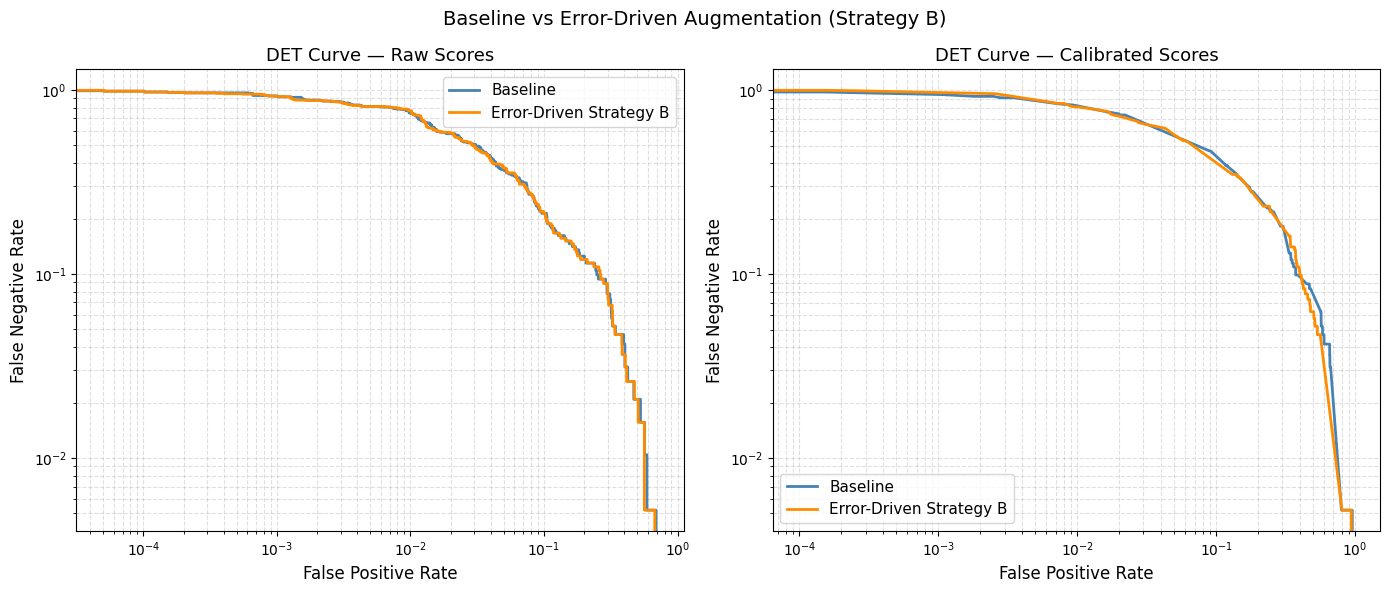

DET curve saved.
              condition  precision_raw  recall_raw  f1_raw  precision_cal  recall_cal  f1_cal  threshold_cal
               Baseline          0.059       0.839   0.110          0.112       0.266   0.158           0.06
Error-Driven Strategy B          0.060       0.833   0.112          0.126       0.229   0.163           0.11

Saved.


In [44]:
# Save metrics
ed_b_metrics = {
    "error_driven_strategy_b": {
        "raw": {
            "threshold": 0.5,
            "precision": round(precision_score(y_test, y_pred_ed_b, zero_division=0), 3),
            "recall": round(recall_score(y_test, y_pred_ed_b), 3),
            "f1": round(f1_score(y_test, y_pred_ed_b, zero_division=0), 3),
        },
        "calibrated": {
            "threshold": round(t_ed_b, 2),
            "precision": round(precision_score(y_test, y_pred_ed_b_cal, zero_division=0), 3),
            "recall": round(recall_score(y_test, y_pred_ed_b_cal), 3),
            "f1": round(f1_score(y_test, y_pred_ed_b_cal, zero_division=0), 3),
        }
    }
}

with open("data/results/error_driven_strategy_b_metrics.json", "w") as f:
    json.dump(ed_b_metrics, f, indent=2)
print("Metrics saved.")

# DET curve
from sklearn.metrics import det_curve

fpr_base, fnr_base, _ = det_curve(y_test, y_scores_base)
fpr_base_cal, fnr_base_cal, _ = det_curve(y_test, y_scores_base_cal)
fpr_ed_b, fnr_ed_b, _ = det_curve(y_test, y_scores_ed_b)
fpr_ed_b_cal, fnr_ed_b_cal, _ = det_curve(y_test, y_scores_ed_b_cal)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(fpr_base, fnr_base, color='steelblue', linewidth=2, label='Baseline')
ax1.plot(fpr_ed_b, fnr_ed_b, color='darkorange', linewidth=2, label='Error-Driven Strategy B')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('False Negative Rate', fontsize=12)
ax1.set_title('DET Curve — Raw Scores', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, which='both', linestyle='--', alpha=0.4)

ax2.plot(fpr_base_cal, fnr_base_cal, color='steelblue', linewidth=2, label='Baseline')
ax2.plot(fpr_ed_b_cal, fnr_ed_b_cal, color='darkorange', linewidth=2, label='Error-Driven Strategy B')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('False Negative Rate', fontsize=12)
ax2.set_title('DET Curve — Calibrated Scores', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, which='both', linestyle='--', alpha=0.4)

plt.suptitle('Baseline vs Error-Driven Augmentation (Strategy B)', fontsize=14)
plt.tight_layout()
plt.savefig("data/results/error_driven_strategy_b_det.png", dpi=150, bbox_inches='tight')
plt.show()
print("DET curve saved.")

# Comparison table
with open("data/results/error_driven_baseline_metrics.json") as f:
    m_base = json.load(f)["baseline"]

rows = [
    {"condition": "Baseline",
     "precision_raw": m_base['raw']['precision'],
     "recall_raw": m_base['raw']['recall'],
     "f1_raw": m_base['raw']['f1'],
     "precision_cal": m_base['calibrated']['precision'],
     "recall_cal": m_base['calibrated']['recall'],
     "f1_cal": m_base['calibrated']['f1'],
     "threshold_cal": m_base['calibrated']['threshold']},
    {"condition": "Error-Driven Strategy B",
     "precision_raw": ed_b_metrics['error_driven_strategy_b']['raw']['precision'],
     "recall_raw": ed_b_metrics['error_driven_strategy_b']['raw']['recall'],
     "f1_raw": ed_b_metrics['error_driven_strategy_b']['raw']['f1'],
     "precision_cal": ed_b_metrics['error_driven_strategy_b']['calibrated']['precision'],
     "recall_cal": ed_b_metrics['error_driven_strategy_b']['calibrated']['recall'],
     "f1_cal": ed_b_metrics['error_driven_strategy_b']['calibrated']['f1'],
     "threshold_cal": ed_b_metrics['error_driven_strategy_b']['calibrated']['threshold']},
]

comparison_df = pd.DataFrame(rows)
comparison_df.to_csv("data/results/error_driven_augmentation_comparison.csv", index=False)
print(comparison_df.to_string(index=False))
print("\nSaved.")